# Chicago Historical Weather EDA

This notebook evaluates the quality and patterns of hourly Chicago weather
data retrieved from the Open-Meteo Historical Weather API.

Questions:

1. Are the timestamps complete, sorted, and unique?
2. Are any weather values missing or invalid?
3. How do temperature and precipitation vary by season?
4. What extreme weather events appear in the data?

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")


repo_root = Path.cwd()

if repo_root.name == "notebooks":
    repo_root = repo_root.parent

raw_path = (
    repo_root
    / "data"
    / "raw"
    / "weather"
    / "open_meteo_chicago_2023-01-01_2024-12-31.json"
)

print(raw_path)
print("File exists:", raw_path.exists())

/Users/andre/Documents/urban-metrics-forecasting/data/raw/weather/open_meteo_chicago_2023-01-01_2024-12-31.json
File exists: True


In [2]:
with raw_path.open() as file:
    payload = json.load(file)

print(payload.keys())
print()
print("Hourly units:")
print(payload["hourly_units"])

dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'hourly_units', 'hourly'])

Hourly units:
{'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'apparent_temperature': '°C', 'precipitation': 'mm', 'rain': 'mm', 'snowfall': 'cm', 'weather_code': 'wmo code', 'wind_speed_10m': 'km/h', 'wind_gusts_10m': 'km/h'}


In [3]:
df = pd.DataFrame(payload["hourly"])

df = df.rename(columns={"time": "timestamp_utc"})

df["timestamp_utc"] = pd.to_datetime(
    df["timestamp_utc"],
    utc=True,
)

df = df.sort_values("timestamp_utc").reset_index(drop=True)

df.head()

,timestamp_utc,temperature_2m,relative_humidity_2m,apparent_temperature,precipitation,rain,snowfall,weather_code,wind_speed_10m,wind_gusts_10m
0,2023-01-01 00:00:00+00:00,-0.2,95,-4.0,0.0,0.0,0.00,3,10.6,17.3
1,2023-01-01 01:00:00+00:00,0.7,94,-3.2,0.0,0.0,0.00,3,11.9,15.5
2,2023-01-01 02:00:00+00:00,0.9,94,-3.6,0.3,0.1,0.14,71,16.3,22.3
3,2023-01-01 03:00:00+00:00,1.0,92,-3.7,0.0,0.0,0.00,3,17.2,25.6
4,2023-01-01 04:00:00+00:00,1.0,91,-2.8,0.0,0.0,0.00,3,10.6,24.5


In [4]:
print("Shape:", df.shape)
print()
df.info()

Shape: (17544, 10)

<class 'pandas.DataFrame'>
RangeIndex: 17544 entries, 0 to 17543
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   timestamp_utc         17544 non-null  datetime64[us, UTC]
 1   temperature_2m        17544 non-null  float64            
 2   relative_humidity_2m  17544 non-null  int64              
 3   apparent_temperature  17544 non-null  float64            
 4   precipitation         17544 non-null  float64            
 5   rain                  17544 non-null  float64            
 6   snowfall              17544 non-null  float64            
 7   weather_code          17544 non-null  int64              
 8   wind_speed_10m        17544 non-null  float64            
 9   wind_gusts_10m        17544 non-null  float64            
dtypes: datetime64[us, UTC](1), float64(7), int64(2)
memory usage: 1.3 MB


In [5]:
print("First timestamp:", df["timestamp_utc"].min())
print("Last timestamp:", df["timestamp_utc"].max())
print("Number of observations:", len(df))

First timestamp: 2023-01-01 00:00:00+00:00
Last timestamp: 2024-12-31 23:00:00+00:00
Number of observations: 17544


In [6]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (
        df.isna().mean() * 100
    ).round(2),
})

missing_summary

,missing_count,missing_percent
timestamp_utc,0,0.0
temperature_2m,0,0.0
relative_humidity_2m,0,0.0
apparent_temperature,0,0.0
precipitation,0,0.0
rain,0,0.0
snowfall,0,0.0
weather_code,0,0.0
wind_speed_10m,0,0.0
wind_gusts_10m,0,0.0


In [7]:
duplicate_count = df["timestamp_utc"].duplicated().sum()

expected_timestamps = pd.date_range(
    start=df["timestamp_utc"].min(),
    end=df["timestamp_utc"].max(),
    freq="h",
    tz="UTC",
)

actual_timestamps = pd.DatetimeIndex(df["timestamp_utc"])

missing_timestamps = expected_timestamps.difference(
    actual_timestamps
)

print("Duplicate timestamps:", duplicate_count)
print("Expected timestamps:", len(expected_timestamps))
print("Actual timestamps:", len(actual_timestamps))
print("Missing timestamps:", len(missing_timestamps))

Duplicate timestamps: 0
Expected timestamps: 17544
Actual timestamps: 17544
Missing timestamps: 0


In [8]:
invalid_humidity = ~df["relative_humidity_2m"].between(
    0,
    100,
)

negative_counts = {
    column: int((df[column] < 0).sum())
    for column in [
        "precipitation",
        "rain",
        "snowfall",
    ]
}

print(
    "Invalid humidity observations:",
    invalid_humidity.sum(),
)

print(
    "Negative weather observations:",
    negative_counts,
)

Invalid humidity observations: 0
Negative weather observations: {'precipitation': 0, 'rain': 0, 'snowfall': 0}


In [9]:
df["timestamp_local"] = (
    df["timestamp_utc"]
    .dt.tz_convert("America/Chicago")
)

df["year"] = df["timestamp_local"].dt.year
df["month"] = df["timestamp_local"].dt.month
df["hour"] = df["timestamp_local"].dt.hour
df["day_of_week"] = df["timestamp_local"].dt.day_name()

df[
    [
        "timestamp_utc",
        "timestamp_local",
        "year",
        "month",
        "hour",
        "day_of_week",
    ]
].head()

,timestamp_utc,timestamp_local,year,month,hour,day_of_week
0,2023-01-01 00:00:00+00:00,2022-12-31 18:00:00-06:00,2022,12,18,Saturday
1,2023-01-01 01:00:00+00:00,2022-12-31 19:00:00-06:00,2022,12,19,Saturday
2,2023-01-01 02:00:00+00:00,2022-12-31 20:00:00-06:00,2022,12,20,Saturday
3,2023-01-01 03:00:00+00:00,2022-12-31 21:00:00-06:00,2022,12,21,Saturday
4,2023-01-01 04:00:00+00:00,2022-12-31 22:00:00-06:00,2022,12,22,Saturday


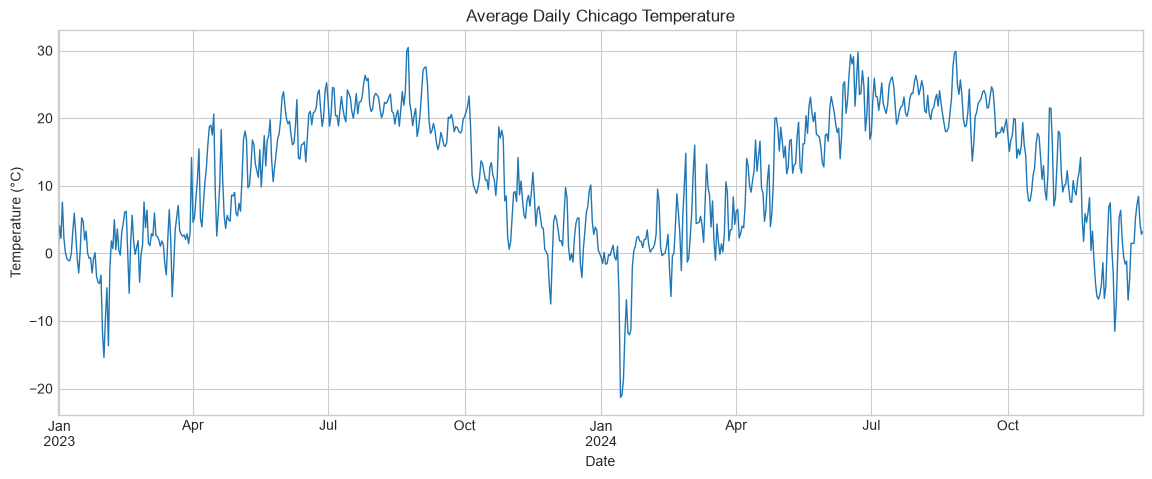

In [10]:
daily_temperature = (
    df.set_index("timestamp_local")["temperature_2m"]
    .resample("D")
    .mean()
)

daily_temperature.plot(
    figsize=(14, 5),
    linewidth=1,
)

plt.title("Average Daily Chicago Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.show()

In [11]:
monthly_temperature = (
    df.groupby("month")["temperature_2m"]
    .agg(["mean", "min", "max"])
)

monthly_temperature

,mean,min,max
month,,,
1,-1.974462,-24.9,12.7
2,1.517032,-17.9,21.8
3,3.945155,-10.6,22.5
4,9.981875,-2.2,26.7
5,15.279301,2.7,31.3
6,20.958889,9.2,34.9
7,22.441398,13.7,32.8
8,22.426546,11.1,37.0
9,19.978472,9.4,34.6


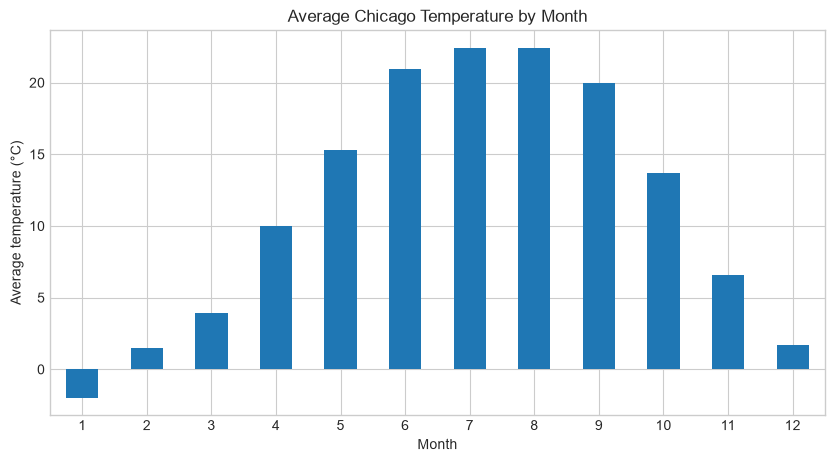

In [13]:
monthly_temperature["mean"].plot(
    kind="bar",
    figsize=(10, 5),
)

plt.title("Average Chicago Temperature by Month")
plt.xlabel("Month")
plt.ylabel("Average temperature (°C)")
plt.xticks(rotation=0)
plt.show()

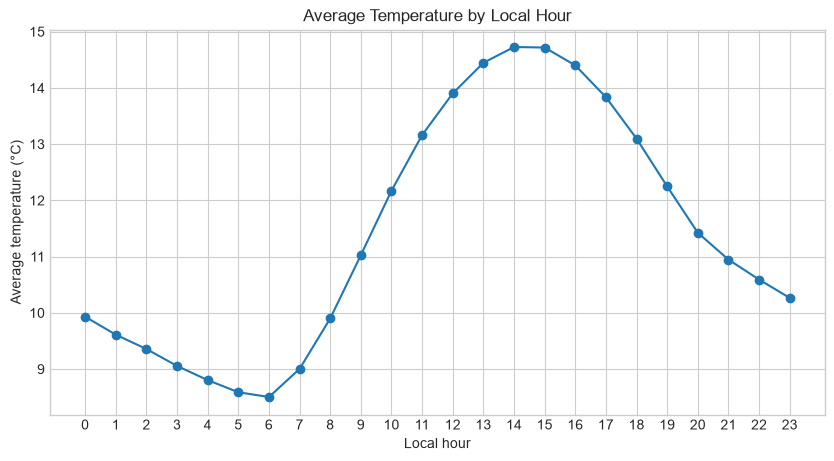

In [14]:
hourly_temperature = (
    df.groupby("hour")["temperature_2m"]
    .mean()
)

hourly_temperature.plot(
    figsize=(10, 5),
    marker="o",
)

plt.title("Average Temperature by Local Hour")
plt.xlabel("Local hour")
plt.ylabel("Average temperature (°C)")
plt.xticks(range(24))
plt.show()

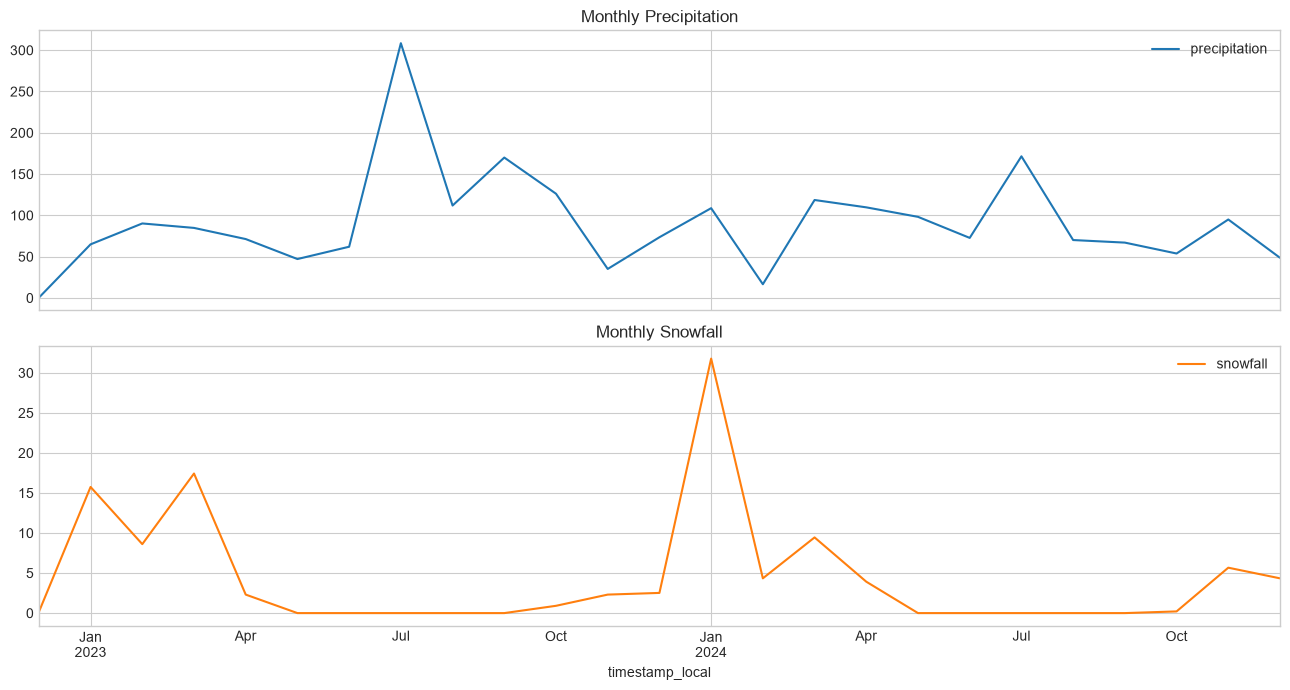

In [15]:
monthly_precipitation = (
    df.set_index("timestamp_local")
    [["precipitation", "snowfall"]]
    .resample("MS")
    .sum()
)

monthly_precipitation.plot(
    subplots=True,
    figsize=(13, 7),
    title=[
        "Monthly Precipitation",
        "Monthly Snowfall",
    ],
)

plt.tight_layout()
plt.show()

In [16]:
print("Coldest observations:")
display(
    df.nsmallest(5, "temperature_2m")[
        ["timestamp_local", "temperature_2m"]
    ]
)

print("Hottest observations:")
display(
    df.nlargest(5, "temperature_2m")[
        ["timestamp_local", "temperature_2m"]
    ]
)

print("Largest precipitation observations:")
display(
    df.nlargest(5, "precipitation")[
        [
            "timestamp_local",
            "precipitation",
            "rain",
            "snowfall",
        ]
    ]
)

print("Largest snowfall observations:")
display(
    df.nlargest(5, "snowfall")[
        [
            "timestamp_local",
            "snowfall",
            "temperature_2m",
        ]
    ]
)

Coldest observations:


,timestamp_local,temperature_2m
9108,2024-01-15 06:00:00-06:00,-24.9
9107,2024-01-15 05:00:00-06:00,-24.8
9106,2024-01-15 04:00:00-06:00,-24.6
9105,2024-01-15 03:00:00-06:00,-24.3
9104,2024-01-15 02:00:00-06:00,-24.2


Hottest observations:


,timestamp_local,temperature_2m
5660,2023-08-24 15:00:00-05:00,37.0
5661,2023-08-24 16:00:00-05:00,37.0
5637,2023-08-23 16:00:00-05:00,36.6
5636,2023-08-23 15:00:00-05:00,36.5
5662,2023-08-24 17:00:00-05:00,36.5


Largest precipitation observations:


,timestamp_local,precipitation,rain,snowfall
4383,2023-07-02 10:00:00-05:00,33.6,33.6,0.0
4384,2023-07-02 11:00:00-05:00,28.7,28.7,0.0
4382,2023-07-02 09:00:00-05:00,24.4,24.4,0.0
4381,2023-07-02 08:00:00-05:00,23.9,23.9,0.0
4959,2023-07-26 10:00:00-05:00,20.0,20.0,0.0


Largest snowfall observations:


,timestamp_local,snowfall,temperature_2m
10716,2024-03-22 07:00:00-05:00,3.29,-0.1
10715,2024-03-22 06:00:00-05:00,2.87,0.3
9037,2024-01-12 07:00:00-06:00,2.52,0.8
16576,2024-11-21 10:00:00-06:00,1.82,0.0
9038,2024-01-12 08:00:00-06:00,1.75,0.9


## Findings

### Data quality

- The dataset contains 17,544 hourly observations.
- The date range is January 1, 2023 through December 31, 2024.
- No duplicate timestamps were found.
- No hourly timestamps were missing.
- No columns contained missing values.
- No invalid humidity or negative precipitation values were found.

### Weather patterns

- Temperature displays clear daily and annual seasonality.
- The warmest temperatures occur during summer.
- The coldest temperatures occur during winter.
- Precipitation occurs throughout the year.
- Snowfall is concentrated in the colder months.

### Extreme observations

- The lowest observed temperature was approximately -24.9°C.
- The highest observed temperature was approximately 37.0°C.
- The largest hourly precipitation was approximately 33.6 mm.
- The largest hourly snowfall was approximately 3.29 cm.

### Next steps

- Create reusable weather feature-engineering functions.
- Add rain, snow, freezing, and rolling accumulation features.
- Preserve UTC as the canonical timestamp for downstream joins.